# **Erosion & Dilation in OpenCV**

## **1. Core idea**

Erosion and dilation are the two basic **morphological operations**. They reshape white regions (the "foreground") in an image by sliding a small window called a **structuring element (kernel)** across it.

- **Erosion** → shrinks white regions. Think of an eraser rubbing away the edges of a white blob. Tiny white noise specks disappear completely.
- **Dilation** → grows white regions. Think of a marker tracing thicker around a white blob's edges. Small black gaps/holes get painted over and filled.

| Operation | Effect on white blob | Effect on small noise | Effect on small holes |
|---|---|---|---|
| Erosion | Shrinks | Removed | No effect |
| Dilation | Grows | Also grows (not removed) | Filled |

They work on **binary images** (0 = black, 255 = white) and **grayscale images** (0–255). They technically run on color images too, but each channel (B, G, R) gets processed independently, which can cause color fringing — so in practice, you usually threshold/segment a color image into a binary mask first, then erode/dilate that mask.

---
## **2. What's happening under the hood**

Both operations are just a **sliding min/max filter**:

1. Center the kernel on a pixel.
2. Look at every pixel value the kernel covers.
3. Replace the center pixel with:
   - the **minimum** of those values → **erosion**
   - the **maximum** of those values → **dilation**
4. Slide to the next pixel, repeat for the entire image.

**Why erosion shrinks white regions:** a white pixel survives only if *every* pixel under the kernel is also white. If even one neighbor is black, the minimum is 0, and the center pixel gets knocked down to black.

**Why dilation grows white regions:** a black pixel becomes white if *even one* pixel under the kernel is white, because the maximum will be 255.

**Why only edges change:** pixels deep inside a solid white blob have every neighbor white too, so min = max = 255 — nothing changes there. Only pixels near a boundary have mixed neighborhoods, so that's the only place the output differs from the input. This is why erosion/dilation visually only "eat into" or "grow out from" the outline of a shape.

---
### **The math (for reference)**

$$(A \ominus B)(x,y) = \min_{(i,j)\, \in\, B} A(x+i,\ y+j) \quad \text{(erosion)}$$

$$(A \oplus B)(x,y) = \max_{(i,j)\, \in\, B} A(x+i,\ y+j) \quad \text{(dilation)}$$

Where $A$ is the image, $B$ is the kernel (the set of offsets to check), and $(x,y)$ is the pixel currently being computed.

---
## **3. Border (edge) pixels**

Near the border of the image, part of the kernel window falls **outside** the image — there's no real data there. OpenCV has to invent values for those missing spots before it can compute min/max. This is called **border handling**, controlled by the `borderType` argument.

Default behavior (`cv2.BORDER_CONSTANT`) is chosen so the padding never artificially distorts the result:
- **Erosion** pads with **white (255)** by default — so padding can't cause a min/black result that the real pixels wouldn't have caused anyway.
- **Dilation** pads with **black (0)** by default — so padding can't cause a max/white result artificially.

Other options: `cv2.BORDER_REPLICATE` (repeats the nearest edge pixel outward), `cv2.BORDER_REFLECT` (mirrors the image across the edge). In practice, the default is almost always correct — only override this if your object of interest actually touches the image boundary or you have unusual requirements (e.g. seamless tiling).

The affected region is only a thin strip around the image edge, roughly half the kernel size wide (e.g. a 5×5 kernel affects a ~2-pixel border strip) — usually a tiny fraction of the total image.

---
## **4. Syntax and arguments**

### **Building the kernel first**

```python
kernel = cv2.getStructuringElement(shape, ksize)
```

| Argument | Meaning |
|---|---|
| `shape` | `cv2.MORPH_RECT` (all neighbors, most aggressive), `cv2.MORPH_CROSS` (only up/down/left/right, gentler), `cv2.MORPH_ELLIPSE` (rounds corners, good for blobs) |
| `ksize` | Tuple `(width, height)`, e.g. `(5, 5)`. Bigger kernel = stronger effect. |

You can also just use a plain NumPy array: `np.ones((5,5), np.uint8)` — equivalent to `MORPH_RECT`.

### **Erosion**

```python
eroded = cv2.erode(src, kernel, iterations=1, borderType=cv2.BORDER_CONSTANT)
```

| Argument | Meaning |
|---|---|
| `src` | Input image (binary or grayscale) |
| `kernel` | The structuring element built above |
| `iterations` | How many times to apply erosion in a row. More iterations = shrinks further (roughly similar to using a bigger kernel, but not identical) |
| `borderType` | How to handle pixels outside the image edge (see Section 3). Default is fine almost always. |

### **Dilation**

```python
dilated = cv2.dilate(src, kernel, iterations=1, borderType=cv2.BORDER_CONSTANT)
```

Same arguments, same meaning — just grows instead of shrinks.

### **Rule of thumb for `src`**

- **Foreground (object) must be white (255)**, background black (0). If your mask is inverted, erosion will visually grow things instead of shrinking — use `cv2.THRESH_BINARY_INV` when thresholding if needed.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

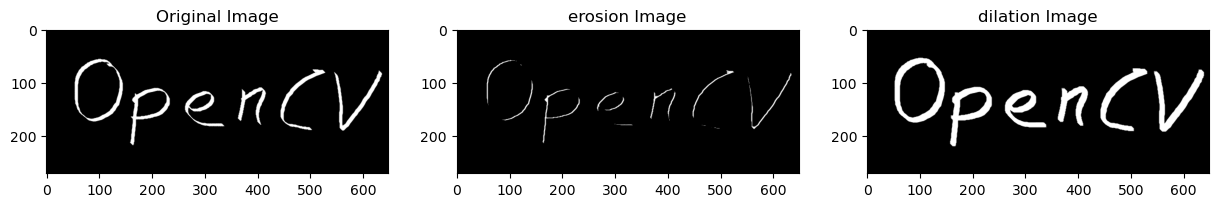

In [2]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\s04\pic04\opencv_inv.png", cv2.IMREAD_GRAYSCALE)
kernel = np.ones((5, 5), dtype=np.uint8)

erosion = cv2.erode(image, kernel, iterations=1)
dilate = cv2.dilate(image, kernel, iterations=1)

plt.figure(figsize=(15, 8))
plt.subplot(131); plt.imshow(image, cmap="gray"); plt.title("Original Image")
plt.subplot(132); plt.imshow(erosion, cmap="gray"); plt.title("erosion Image")
plt.subplot(133); plt.imshow(dilate, cmap="gray"); plt.title("dilation Image")
plt.show()

# **Opening and Closing**

Opening and closing are just erosion and dilation **combined**, applied back-to-back in a specific order.

---
## **Opening = Erode, then Dilate**

**Opening = erosion first, then dilation on the result.**

- Erosion erases small white noise specks completely (they're too small to survive).
- Dilation then grows the remaining (real) objects back to roughly their original size.

**Net effect:** small white noise disappears, big objects stay roughly the same size.

Use opening to **clean up small white specks/noise** in a binary image.

---
## **Closing = Dilate, then Erode**

**Closing = dilation first, then erosion on the result.**

- Dilation fills in small black holes/gaps inside a white object (paints over them).
- Erosion then shrinks the object back down — but the holes are already gone, so they don't reappear.

**Net effect:** small black holes/gaps get filled, big objects stay roughly the same size.

Use closing to **fill small holes or connect nearby broken pieces** of a shape.

---
### **Mnemonic**

- **Opening** → removes small **white** noise
- **Closing** → fills small **black** holes

---
### **Syntax**

```python
kernel = np.ones((5, 5), np.uint8)

opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)  # erode -> dilate
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)  # dilate -> erode
```

`morphologyEx` just runs erosion + dilation internally in the right order — you *could* call `cv2.erode()` then `cv2.dilate()` yourself, but this is cleaner and communicates intent.

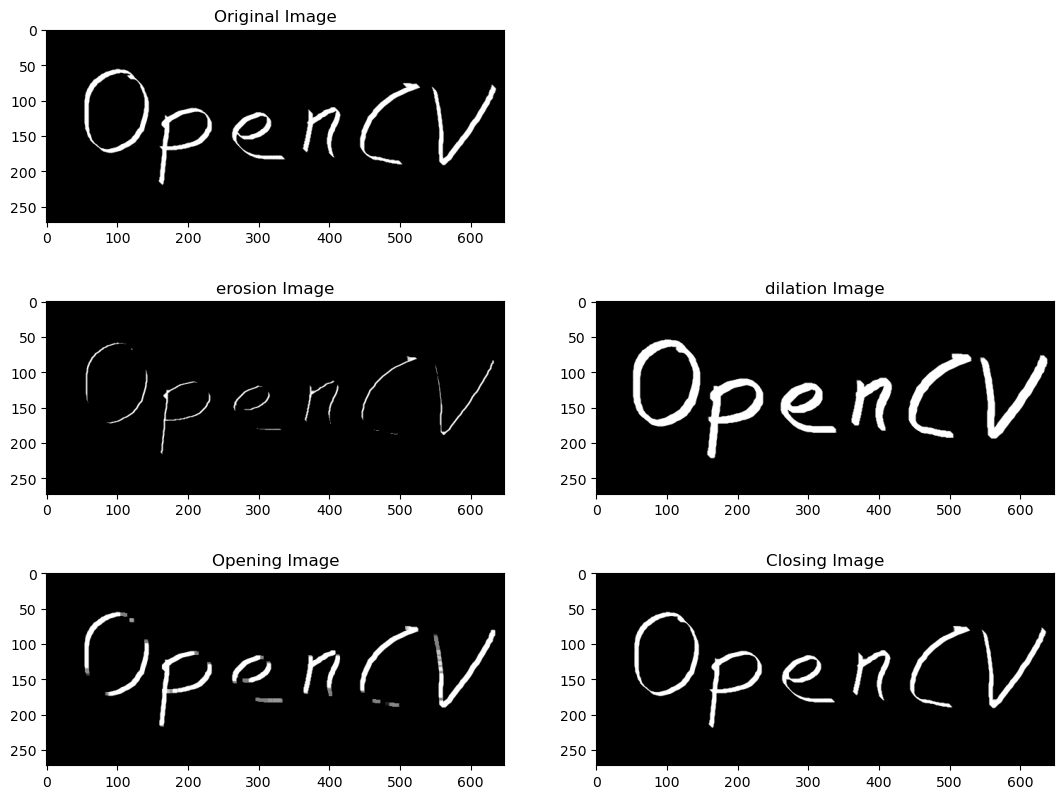

In [7]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\s04\pic04\opencv_inv.png", cv2.IMREAD_GRAYSCALE)
kernel = np.ones((5, 5), dtype=np.uint8)

opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(13, 10))
plt.subplot(321); plt.imshow(image, cmap="gray"); plt.title("Original Image")
plt.subplot(323); plt.imshow(erosion, cmap="gray"); plt.title("erosion Image")
plt.subplot(324); plt.imshow(dilate, cmap="gray"); plt.title("dilation Image")
plt.subplot(325); plt.imshow(opening, cmap="gray"); plt.title("Opening Image")
plt.subplot(326); plt.imshow(closing, cmap="gray"); plt.title("Closing Image")
plt.show()

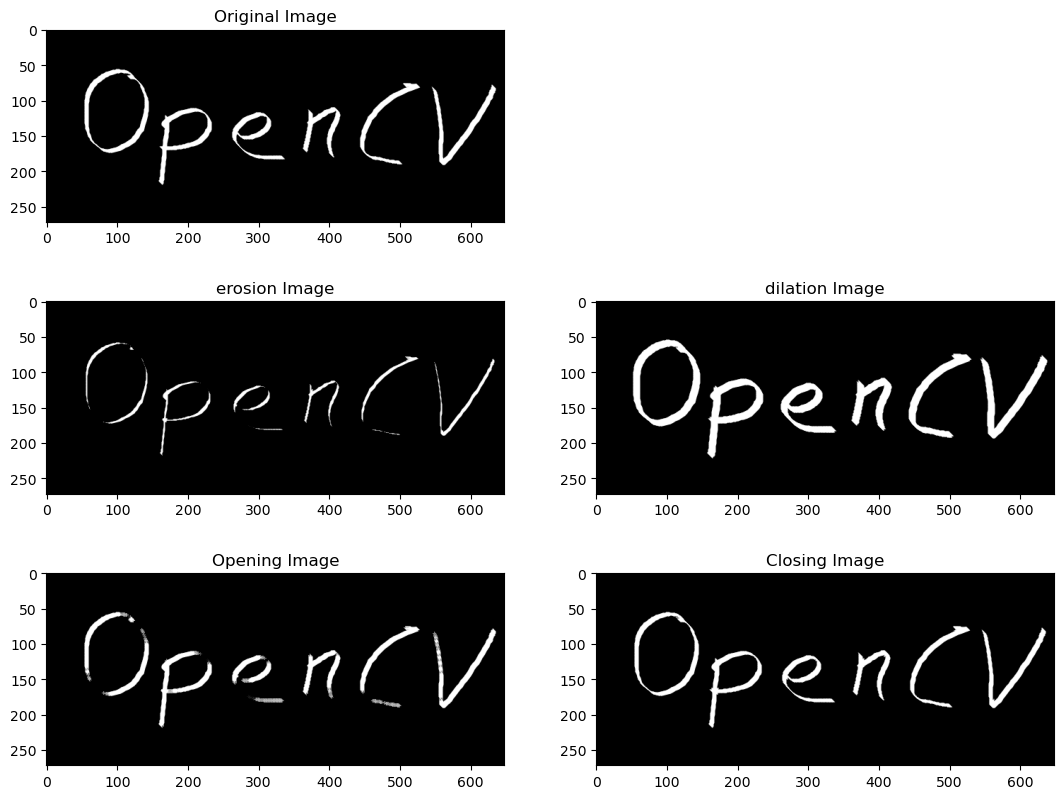

In [4]:
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5), (2, 2))

erosion = cv2.erode(image, kernel, iterations=1)
dilate = cv2.dilate(image, kernel, iterations=1)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(13, 10))
plt.subplot(321); plt.imshow(image, cmap="gray"); plt.title("Original Image")
plt.subplot(323); plt.imshow(erosion, cmap="gray"); plt.title("erosion Image")
plt.subplot(324); plt.imshow(dilate, cmap="gray"); plt.title("dilation Image")
plt.subplot(325); plt.imshow(opening, cmap="gray"); plt.title("Opening Image")
plt.subplot(326); plt.imshow(closing, cmap="gray"); plt.title("Closing Image")
plt.show()

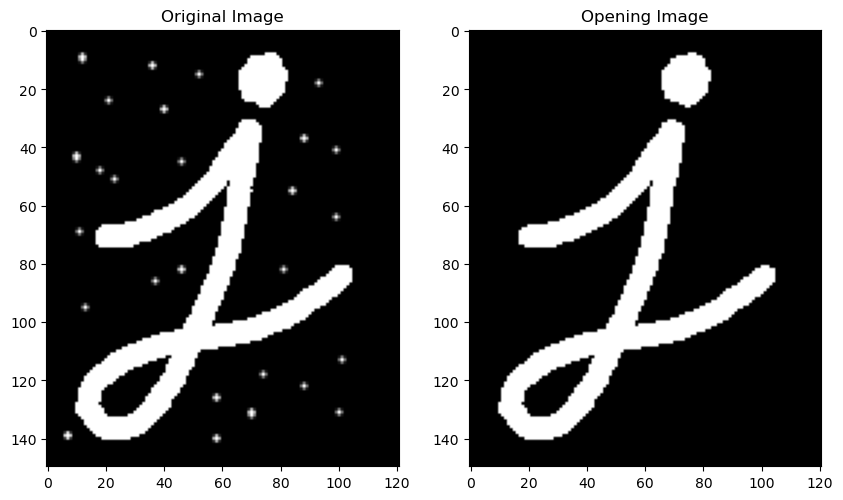

In [12]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\s04\pic04\Opening.png", cv2.IMREAD_GRAYSCALE)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(10, 8))
plt.subplot(121); plt.imshow(image, cmap="gray"); plt.title("Original Image")
plt.subplot(122); plt.imshow(opening, cmap="gray"); plt.title("Opening Image")
plt.show()

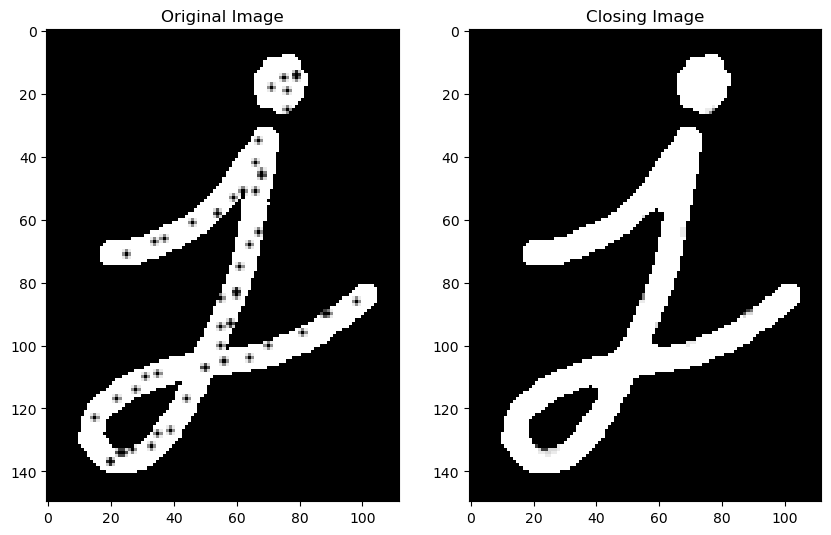

In [13]:
image = cv2.imread(r"C:\Users\DELL\Desktop\resources\ComputerVision\Computer Vision\Computer Vision Sessions\04s\s04\pic04\closing.png", cv2.IMREAD_GRAYSCALE)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(10, 8))
plt.subplot(121); plt.imshow(image, cmap="gray"); plt.title("Original Image")
plt.subplot(122); plt.imshow(closing, cmap="gray"); plt.title("Closing Image")
plt.show()